In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import OrdinalEncoder

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
zscores_plasmid_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid.csv")
zscores_plasmid_unambiguous_VEPannotated_all_features =pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-plasmid.csv")
annotated_control_vs_plasmid_EG = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_52331/2732026987.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid.csv")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_52331/2732026987.py:2: DtypeWarning: Columns (7,26,111,112,113,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_unambiguous_VEPannotated_all_features =pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-plasmid.csv")


In [ ]:
zscores_plasmid_unambiguous_VEPannotated.head()

In [ ]:
zscores_plasmid_unambiguous_VEPannotated_all_features.head()

### Filter for Plasmid vs Control Loss of function mutations and gain of function

In [20]:
#Filter for negative or non-hits
#lof_df = annotated_control_vs_plasmid_EG[(annotated_control_vs_plasmid_EG['Hit_class'] == 'negative') | (annotated_control_vs_plasmid_EG['Hit_class']=='non-hit')].copy()
lof_df = annotated_control_vs_plasmid_EG[(annotated_control_vs_plasmid_EG['Hit_class'] == 'negative')].copy()

In [28]:
#Filter for positive hits
gof_df = annotated_control_vs_plasmid_EG[(annotated_control_vs_plasmid_EG['Hit_class'] == 'positive')].copy()

In [34]:
gof_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score
220,AAATGACATTTATTATGCTT,CBE,NF1,A375,DO,1.357725,positive,ENST00000358273.9,NM_001042492.3,Asp1781Asp,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.143,NaN,NaN,NaN,26.0,23.0,-22.0,0.0,0.0,0.0,0.0,0.0,NaN,0.249,-0.078130,NaN
880,ACAAGACAGGTAAGTAACAC,CBE,KRAS,A375,DO,1.615921,positive,ENST00000311936.8,NM_004985.5,Gln150Ter,4.0,3.0,1.0,NaN,NaN,NaN,0.837745,NaN,NaN,0.655873,0.997386,NaN,NaN,26.496670,1.094883,5.52,5.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,861.0,0.927041,NaN,1.0,9.984,47.000,9.664,1.194,10.858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.264,0.741019,0.998669
917,ACACAGTTCGGAAAGACTAC,CBE,PIK3CB,A375,DO,1.192397,positive,ENST00000674063.1,NM_006219.3,Thr1063Ile,3.0,2.0,NaN,0.1,0.009,NaN,0.716015,0.3014,NaN,-0.235747,0.993656,0.70231,-7.262,3.015186,0.164603,5.55,5.55,NaN,0.51059,NaN,NaN,NaN,-0.9174,0.048558,0.38,NaN,1.0,0.352118,851.0,0.391042,NaN,1.0,3.401,23.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN
1673,AGACAAGAACAAAGGAGAAA,CBE,PIK3CA,A375,DO,1.143887,positive,ENST00000263967.4,NM_006218.4,Asp883Asp,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.378,NaN,NaN,NaN,-2.0,-11.0,-47.0,17.0,0.0,0.0,0.0,0.0,NaN,0.221,NaN,NaN
1794,AGATCAGGTAAGTCTGTGCT,CBE,RAF1,A375,DO,1.062727,positive,ENST00000251849.9,NM_002880.4,Gln556Ter,4.0,3.0,1.0,NaN,NaN,NaN,0.988106,NaN,NaN,0.617010,0.997722,NaN,NaN,30.187840,1.124725,5.54,5.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,692.0,0.941203,NaN,1.0,9.800,50.000,9.664,1.194,10.858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.351,NaN,0.998759


In [29]:
gof_df['Hit_class'].value_counts()

Hit_class
positive    211
Name: count, dtype: int64

# Check Correlation 

In [36]:
meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits',
    'Hit_class'
]

training_features_df = annotated_control_vs_plasmid_EG.drop(columns=meta_cols)

print(f"Shape of feature dataset: {training_features_df.shape}")

Shape of feature dataset: (28086, 50)


In [37]:
# Compute correlation matrix
corr_matrix = training_features_df.corr()
corr_matrix

,zscore,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score
zscore,1.000000,-0.130529,-0.140707,-0.001779,0.046711,-0.089675,-0.113250,-0.065520,-0.125292,-0.152154,-0.167323,-0.043185,-0.074664,0.139725,-0.150014,-0.106916,0.016099,-0.022888,-0.050917,-0.070997,-0.072675,-0.073324,-0.119665,-0.129336,-0.076839,-0.108417,0.106178,0.061480,-0.131227,0.000348,0.015471,-0.119387,-0.041804,-0.070128,-0.150489,0.131786,-0.206455,-0.052765,-0.006818,-0.027762,-0.012508,0.022161,-0.059392,-0.087076,0.005434,-0.005584,0.043304,0.050710,-0.107962,-0.144879
Mutation_Category_enc,-0.130529,1.000000,0.905296,0.041964,NaN,NaN,NaN,0.028726,NaN,NaN,0.585827,0.091236,NaN,NaN,0.423798,0.261700,0.003030,0.003342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006059,-0.432021,NaN,0.026501,0.005404,0.759600,-0.608450,0.729283,-0.065800,0.008412,0.056811,0.044710,-0.039259,0.293863,0.389052,0.069801,0.198407,NaN,-0.046727,0.267028,0.727381
IMPACT_enc,-0.140707,0.905296,1.000000,0.043831,-0.018499,-0.022300,NaN,0.034863,NaN,NaN,0.585414,0.091944,-0.024576,0.000339,0.416548,0.257278,-0.008265,0.001328,-0.000969,NaN,NaN,0.029013,0.066543,0.004012,0.008331,NaN,0.021891,0.010192,0.032893,0.008953,-0.439655,0.005870,0.027071,0.002654,0.876895,-0.608086,0.747509,-0.039970,-0.008242,0.080123,0.048556,-0.049471,0.221086,0.295948,0.061770,0.121675,0.028281,-0.056507,0.266847,0.734148
TSL,-0.001779,0.041964,0.043831,1.000000,0.005874,0.024283,0.064217,0.057208,0.068766,0.014177,0.086280,0.012072,0.087535,0.048637,0.020032,0.062052,0.060830,0.077224,0.083978,0.145133,0.187181,0.069926,0.075410,-0.005379,0.208417,-0.016708,0.008595,-0.134959,0.107139,0.153736,0.010007,0.100154,0.067629,0.092850,0.049494,-0.021713,0.045221,0.024693,0.035430,-0.018803,-0.030341,0.000953,-0.011069,0.018618,-0.014972,0.023857,-0.010110,-0.179384,NaN,0.006361
SIFT_pathogenicity,0.046711,NaN,-0.018499,0.005874,1.000000,-0.409932,-0.371475,-0.478703,-0.403917,-0.393714,-0.409420,-0.461411,-0.366332,0.376914,-0.394894,-0.517805,-0.017138,-0.297520,-0.380695,-0.396723,-0.360320,-0.306171,-0.486930,-0.330907,-0.252471,-0.437813,0.422321,0.258669,-0.394690,0.002022,-0.506605,-0.377530,-0.281434,-0.411349,-0.560414,0.119608,-0.040897,0.127385,-0.021866,0.040778,0.017506,0.006219,-0.007435,-0.010425,0.071674,0.021024,0.151486,0.082137,-0.095667,-0.133957
PolyPhen_pathogenicity,-0.089675,NaN,-0.022300,0.024283,-0.409932,1.000000,0.649096,0.546239,0.643970,0.720157,0.579406,0.273473,0.509666,-0.551208,0.716160,0.659693,0.014305,0.248812,0.381355,0.574842,0.577268,0.387202,0.719744,0.585208,0.241238,0.557879,-0.619469,-0.321997,0.648419,0.035194,0.492273,0.585297,0.243396,0.429713,0.643970,0.001703,-0.030632,-0.022906,-0.003684,0.008047,0.051429,0.001604,0.003899,-0.019101,-0.018789,-0.000996,-0.250695,0.001592,0.306215,0.064460
REVEL,-0.113250,NaN,NaN,0.064217,-0.371475,0.649096,1.000000,0.547020,0.716687,0.657477,0.878870,0.227936,0.684996,-0.669999,0.684997,0.625170,0.031575,0.289047,0.401234,0.569536,0.619661,0.670617,0.848802,0.875587,0.463928,0.578161,-0.719111,-0.448149,0.774305,0.016409,0.580686,0.688632,0.297423,0.517560,0.600708,-0.044542,0.050429,-0.018254,0.017050,0.006952,0.042536,0.004821,0.000442,0.000097,-0.039276,0.015669,-0.292667,-0.071600,0.358636,0.245384
ClinPred,-0.065520,0.02872

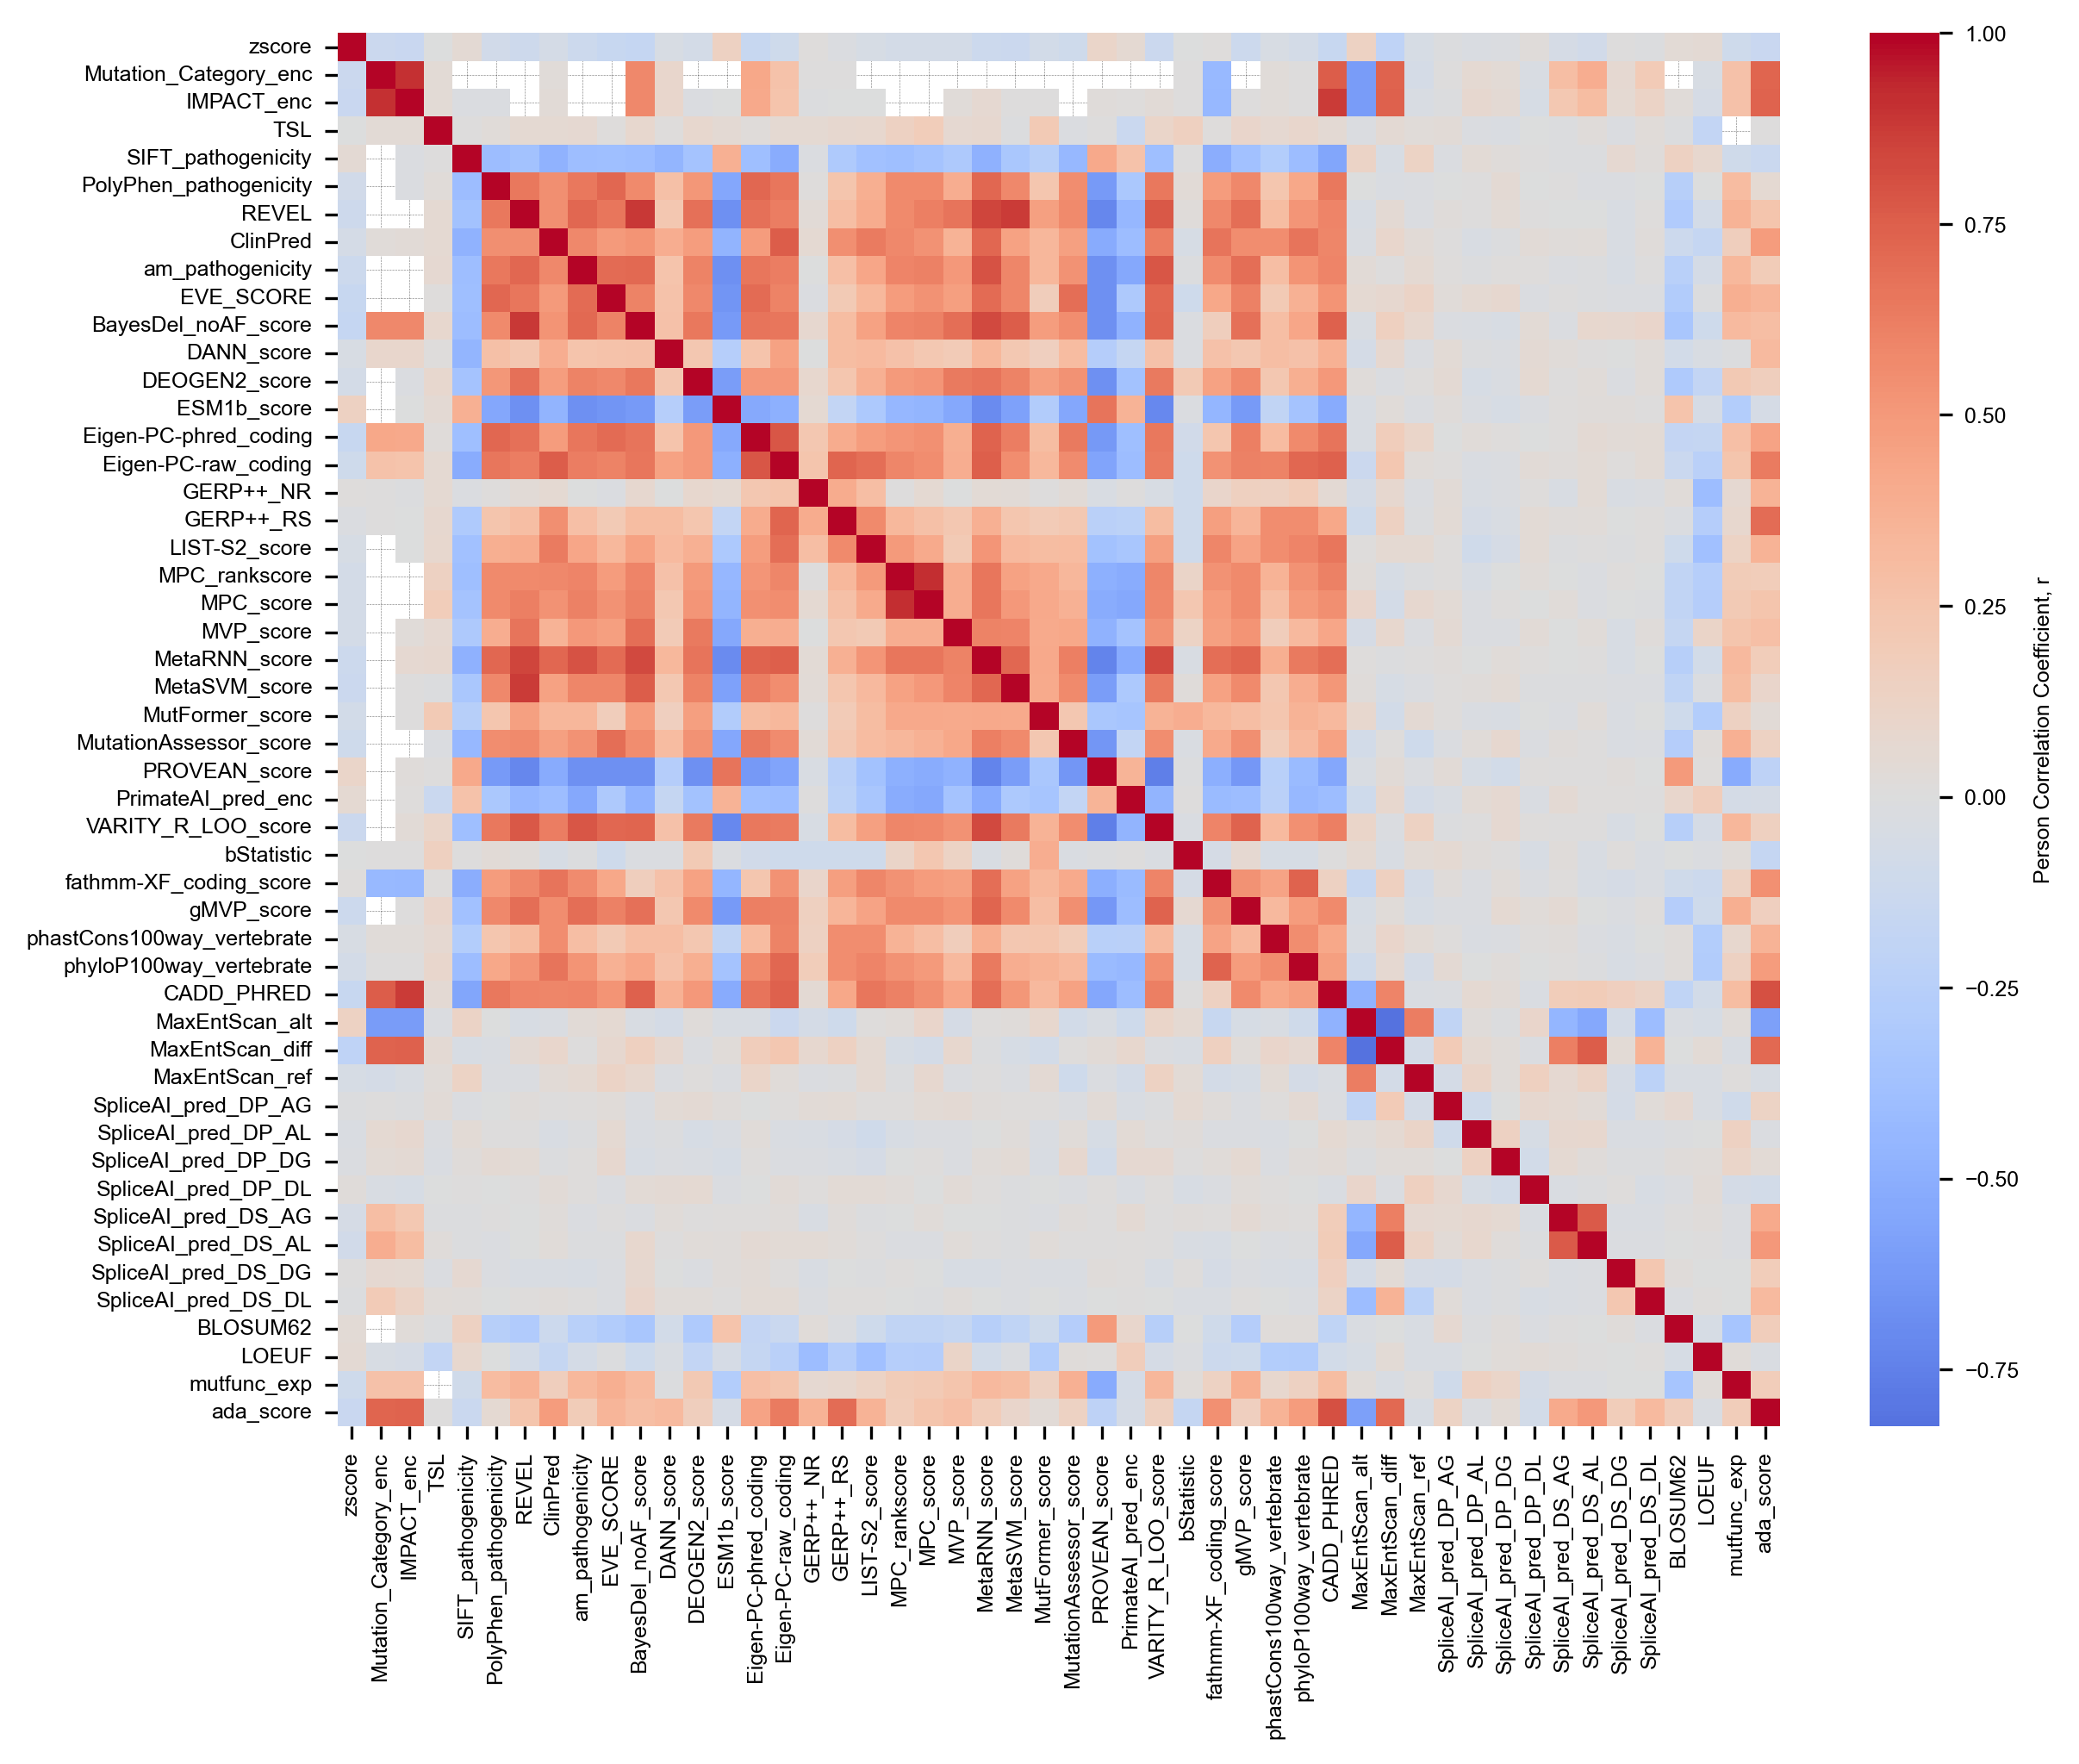

In [38]:
# Plot heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar_kws={'label': 'Person Correlation Coefficient, r'})
plt.show()

In [39]:
# Top 5 features most positively correlated with z-score
top_5_positive_corr = corr_matrix['zscore'].sort_values(ascending=False).head(6)
print(f'Top 5 features most positively correlated with z-score:')
print(top_5_positive_corr)  # Including 'zscore' itself


Top 5 features most positively correlated with z-score:
zscore                1.000000
ESM1b_score           0.139725
MaxEntScan_alt        0.131786
PROVEAN_score         0.106178
PrimateAI_pred_enc    0.061480
LOEUF                 0.050710
Name: zscore, dtype: float64


In [40]:
# Top 5 features most negatively correlated with z-score
top_5_negative_corr = corr_matrix['zscore'].sort_values(ascending=True).head(5)
print(f'Top 5 features most negatively correlated with z-score:')
print(top_5_negative_corr)

Top 5 features most negatively correlated with z-score:
MaxEntScan_diff         -0.206455
BayesDel_noAF_score     -0.167323
EVE_SCORE               -0.152154
CADD_PHRED              -0.150489
Eigen-PC-phred_coding   -0.150014
Name: zscore, dtype: float64


In [21]:
def plot_gene_conditions(
    df: pd.DataFrame,
    gene: str,
    vep_col: str,
    colorbar_label: str = None,
    condition_cols=("Cell_Line", "Drug"),
    point_size: int = 18,
    cmap: str = "viridis",
    max_cols: int = 3,
):
    # Filter by gene
    data = df[df["Gene"] == gene].copy()
    if data.empty:
        print(f"No data for gene {gene}")
        return

    # Build a readable condition string
    plus_sep = " + "
    base = data.loc[:, condition_cols].astype(str).agg(plus_sep.join, axis=1)
    if "Source" in data.columns:
        src = data["Source"].fillna("")
        data["Condition"] = np.where(src.eq(""), base, base + " | " + src.astype(str))
    else:
        data["Condition"] = base

    conditions = data["Condition"].unique()
    n = len(conditions)

    # Grid geometry + figure size that scales with n
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)
    fig_w = 4.5 * ncols
    fig_h = 3.8 * nrows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=False,
        squeeze=False
    )
    fig.subplots_adjust(hspace=0.6, wspace=0.25)

    # Color scaling shared across all subplots
    vmin = data[vep_col].min()
    vmax = data[vep_col].max()

    # Global symmetric y-axis across all subplots
    y_absmax = max(abs(data["zscore"].min()), abs(data["zscore"].max()))
    y_min, y_max = -y_absmax, y_absmax

    # Plot each condition
    last_sc = None
    for ax, cond in zip(axes.ravel(), conditions):
        sub = data[data["Condition"] == cond]
        last_sc = ax.scatter(
            sub["Protein_position"],
            sub["zscore"],
            c=sub[vep_col],
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=0.8,
            edgecolors="none"
        )
        ax.set_title(cond, fontsize=10)
        ax.set_xlabel("Protein position", fontsize=9)
        ax.set_ylabel("Z-score", fontsize=9)
        ax.tick_params(labelsize=8)

        # Force symmetric y-limits centered at 0
        ax.set_ylim(y_min, y_max)
        ax.axhline(0, color="gray", lw=0.8, linestyle="--")  # optional zero reference line

    # Hide unused axes
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    # Shared colorbar
    if last_sc is not None:
        cbar = fig.colorbar(
            last_sc,
            ax=axes.ravel().tolist(),
            location="right",
            shrink=0.5,
            pad=0.02,
            aspect=25
        )
        cbar.set_label(colorbar_label if colorbar_label else vep_col, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    plt.show()

In [ ]:
plot_gene_conditions(
    df=zscores_plasmid_vs_control_annotated_all_features_hits,
    gene="PIK3CA",
    vep_col="AlphaMissense_score",
    colorbar_label="AlphaMissense score",
    condition_cols=["Cell_Line", "Drug"],
)